# 030.Decision Tree

### iris dataset

iris.feature_names : 

Sepal Length : 꽃받침 길이  
Sepal Width  : 꽃받침 너비   
Petal Length  : 꽃잎 길이  
Petal Width   :  꽃잎 너비 

Species (꽃의 종류) :  setosa / versicolor / virginica 의 3종류로 구분된다.

**위 feature 를 모두 가지고 Decision Tree 알고리즘을 이용하여 꽃의 종류 분류**

In [1]:
# 필요한 라이브러리 import
from sklearn.datasets import load_iris  # 아이리스 데이터셋
from sklearn import tree  # 결정 트리 알고리즘

# 아이리스 데이터셋 로드
iris = load_iris()

In [2]:
# 데이터셋의 크기 확인 (샘플 수, 특성 수)
iris.data.shape

(150, 4)

In [3]:
# 특성 이름 확인
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

### train / test split & accuracy check

In [4]:
# 필요한 함수 import
from sklearn.model_selection import train_test_split  # 데이터 분할
from sklearn.metrics import accuracy_score  # 정확도 평가

In [5]:
# 학습/테스트 데이터셋 분할
# test_size=0.3: 전체 데이터의 30%를 테스트 세트로 사용
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3)

In [6]:
# 결정 트리 분류기 객체 생성
# max_depth=2: 트리의 최대 깊이를 2로 제한 (과적합 방지)
# criterion='entropy': 엔트로피를 사용하여 분할 기준 결정
clf = tree.DecisionTreeClassifier(max_depth=2, criterion='entropy')
# 학습 데이터로 모델 훈련
clf.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [7]:
# 테스트 데이터에 대한 예측 수행
y_pred = clf.predict(X_test)

In [8]:
# 정확도 계산: 올바르게 예측한 샘플의 비율
accuracy_score(y_test, y_pred)

0.9777777777777777

## 결정 기준 시각화

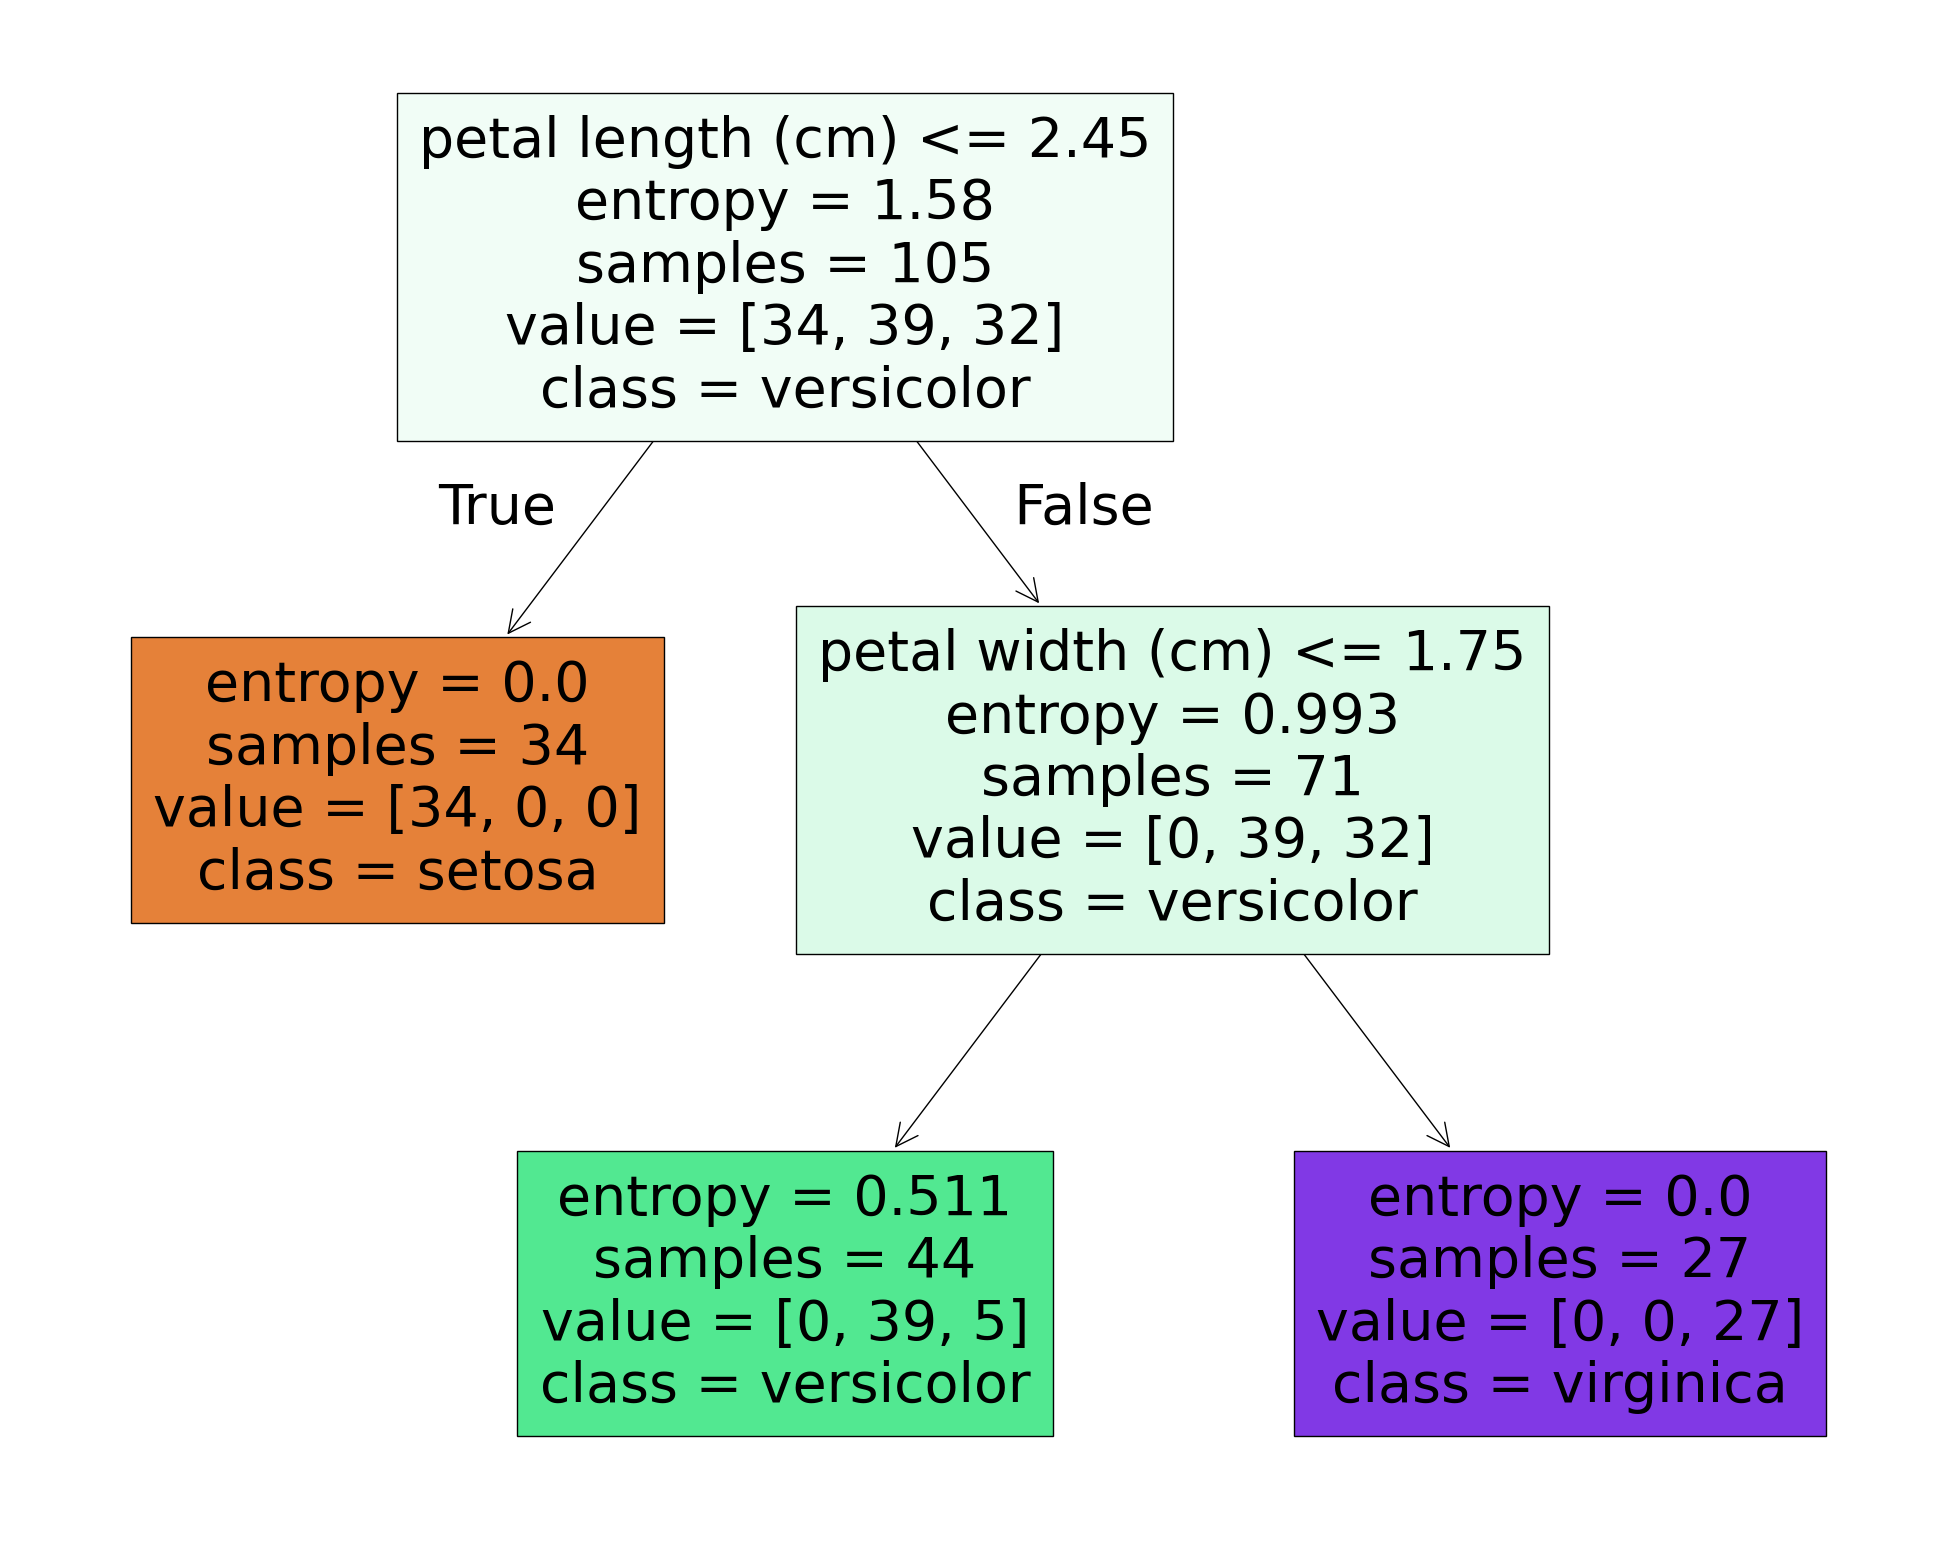

In [9]:
# 시각화를 위한 라이브러리 import
import matplotlib.pyplot as plt

# 결정 트리 시각화
# figsize=(25,20): 그래프 크기 설정
fig = plt.figure(figsize=(25,20))
# 결정 트리 구조를 그래프로 그리기
# feature_names: 특성 이름 표시
# class_names: 클래스 이름 표시
# filled=True: 노드를 색상으로 채워서 표시
_ = tree.plot_tree(clf, 
                   feature_names=iris.feature_names,  
                   class_names=iris.target_names,
                   filled=True)

In [10]:
# 최대 깊이 제한 없이 결정 트리 분류기 생성
# max_depth=None: 트리 깊이 제한 없음 (완전히 성장할 때까지 분할)
clf = tree.DecisionTreeClassifier(max_depth=None)
# 학습 데이터로 모델 훈련
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [11]:
# 테스트 데이터에 대한 예측 수행
y_pred = clf.predict(X_test)
# 정확도 계산 및 출력
accuracy_score(y_test, y_pred)

0.9777777777777777

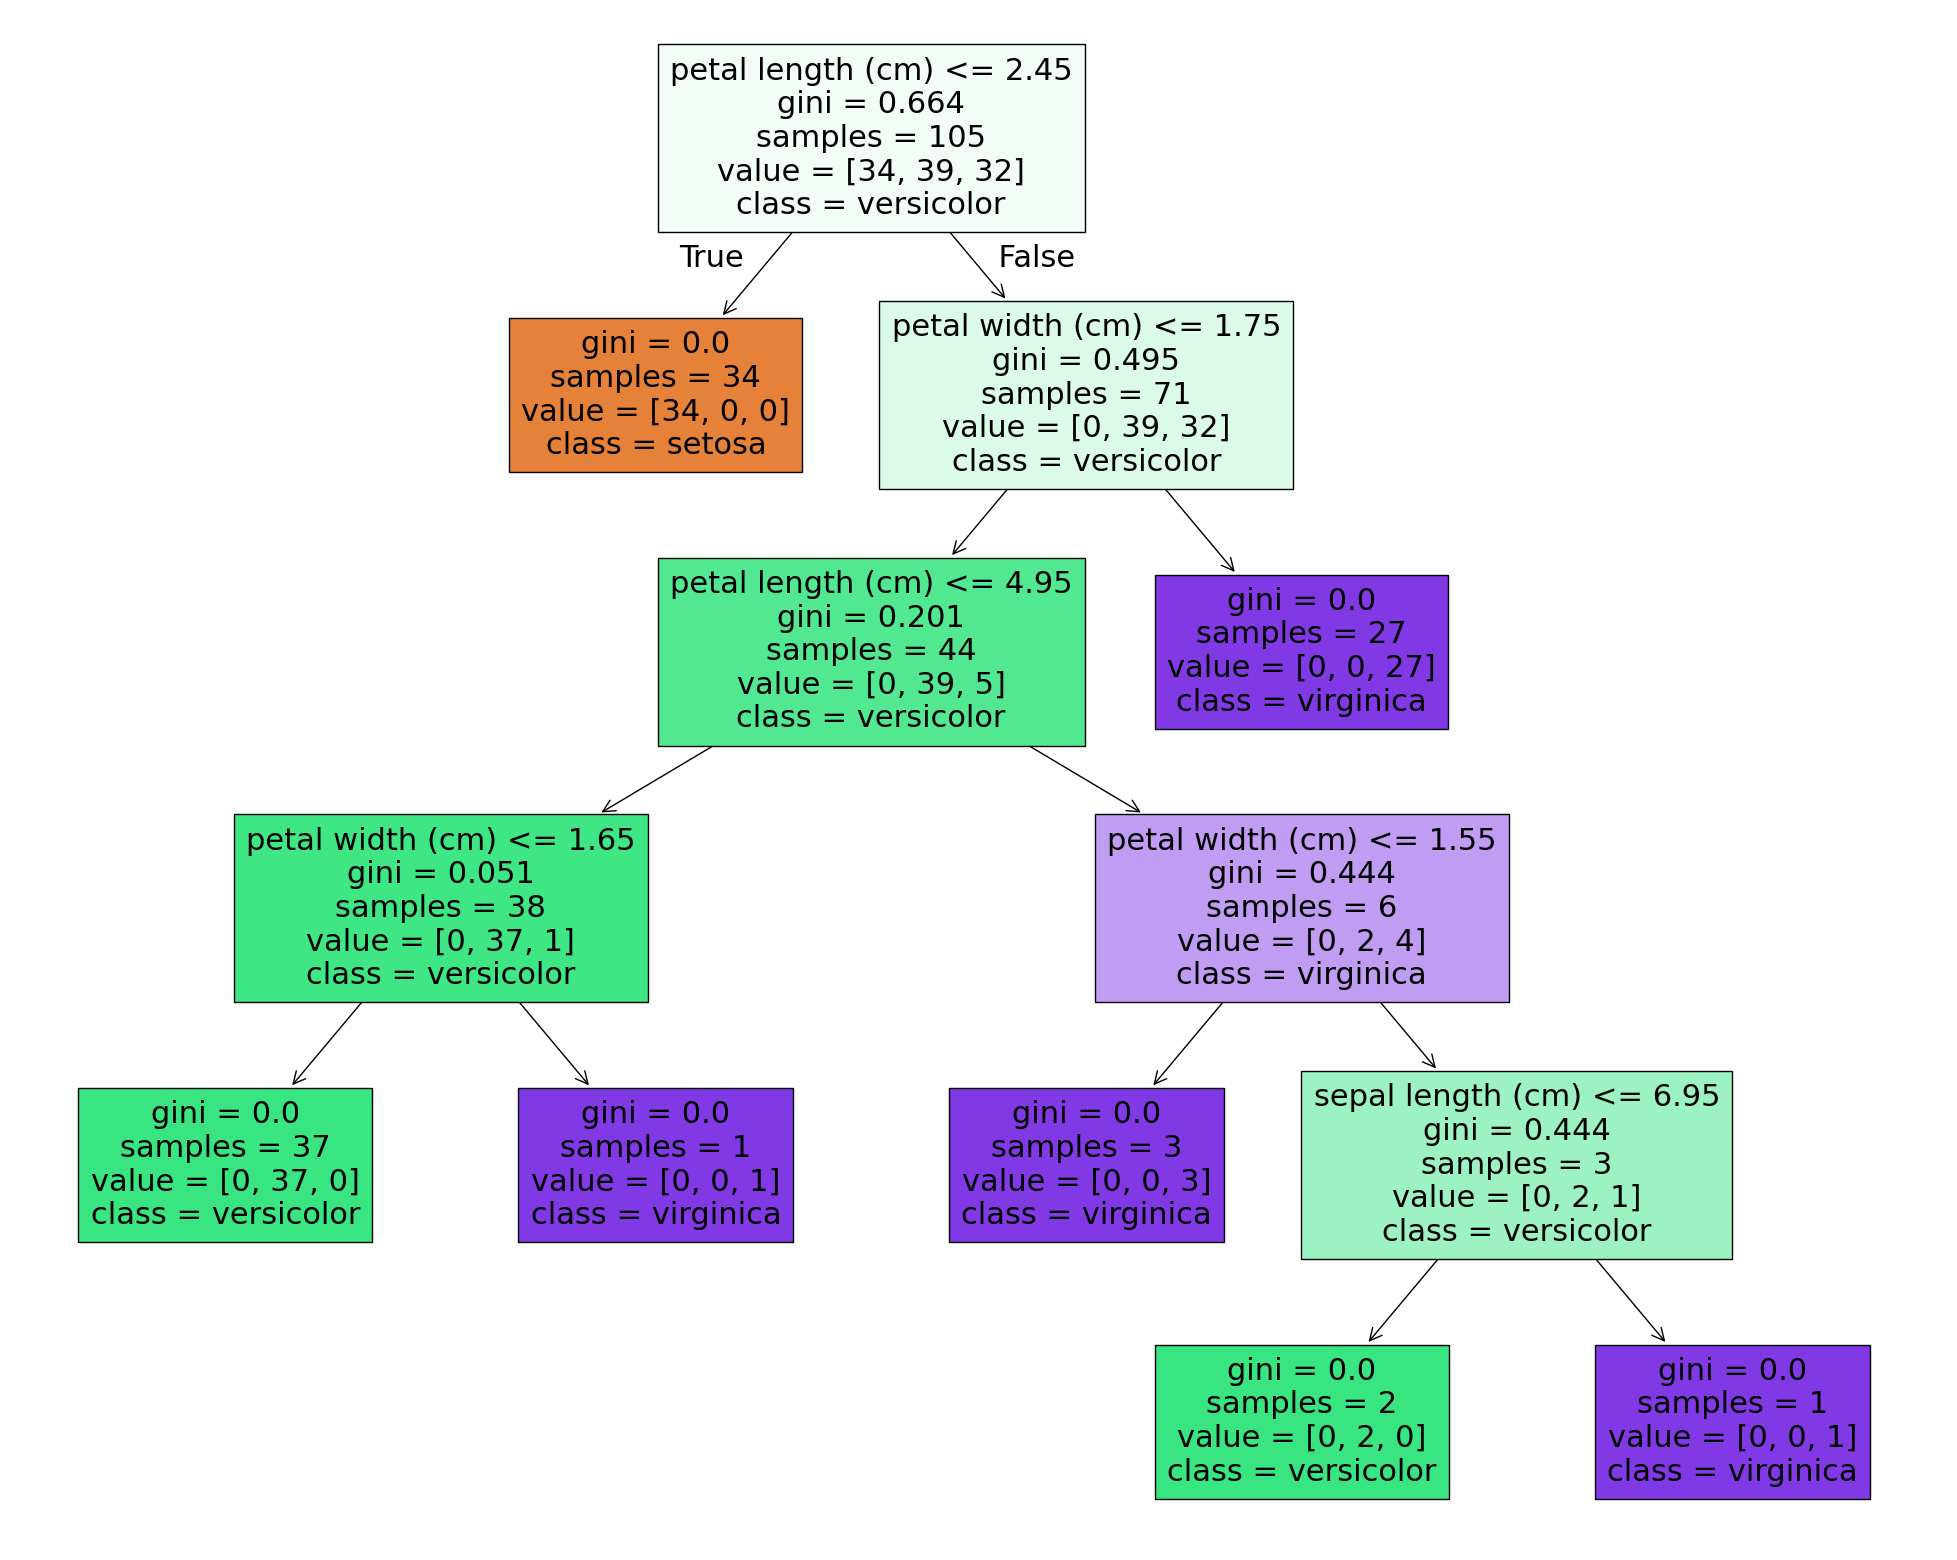

In [12]:
# 깊이 제한 없는 결정 트리 시각화
# max_depth=None으로 생성된 트리는 더 복잡한 구조를 가짐
fig = plt.figure(figsize=(25,20))
# 결정 트리 구조를 그래프로 그리기
_ = tree.plot_tree(clf, 
                   feature_names=iris.feature_names,  
                   class_names=iris.target_names,
                   filled=True)